# Models 1 and 2 - Fixed service batch sizes (diagrams for paper)

## Load libraries

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import libs.tools as tools
import libs.QueueApprox as QueueApprox

plt.style.use('seaborn-v0_8')

## Load and process data

In [12]:
# Number of operators needed in bS=1 case
c_needed = 16

# bI=1, bS=1..16
data_bI1 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed"  and rec["bI"] == 1)
tools.load_statistics(data_bI1)

# bI=1..4, bS=16
data_bI1234 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == c_needed and isinstance(rec["bI"], int))
tools.load_statistics(data_bI1234)

### Calculate relative E[W] changes (to $b_I$=1 or $b_S$=1)

In [13]:
# Changes relative zu bS=1
for rec in data_bI1:
    if rec["b_max"] == 1:
        rec["E[W]rel"] = 1
    else:
        base = tools.find_same_with_other_b(data_bI1, rec, None, 1, 1, None)
        rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

# Changes relative zu bI=1
for rec in data_bI1234:
    if rec["bI"] == 1:
        rec["E[W]rel"] = 1
    else:
        base = tools.find_same_with_other_b(data_bI1, rec, 1, None, None, None)
        rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

## Plotting ($b_I=1$, $b_S=1,\ldots,16$ (at $\rho\in\{60\%,75\%,90\%\}$ and $CV[S]\in\{0.5,1,1.5\}$))

### Plot E[W] (absolute)

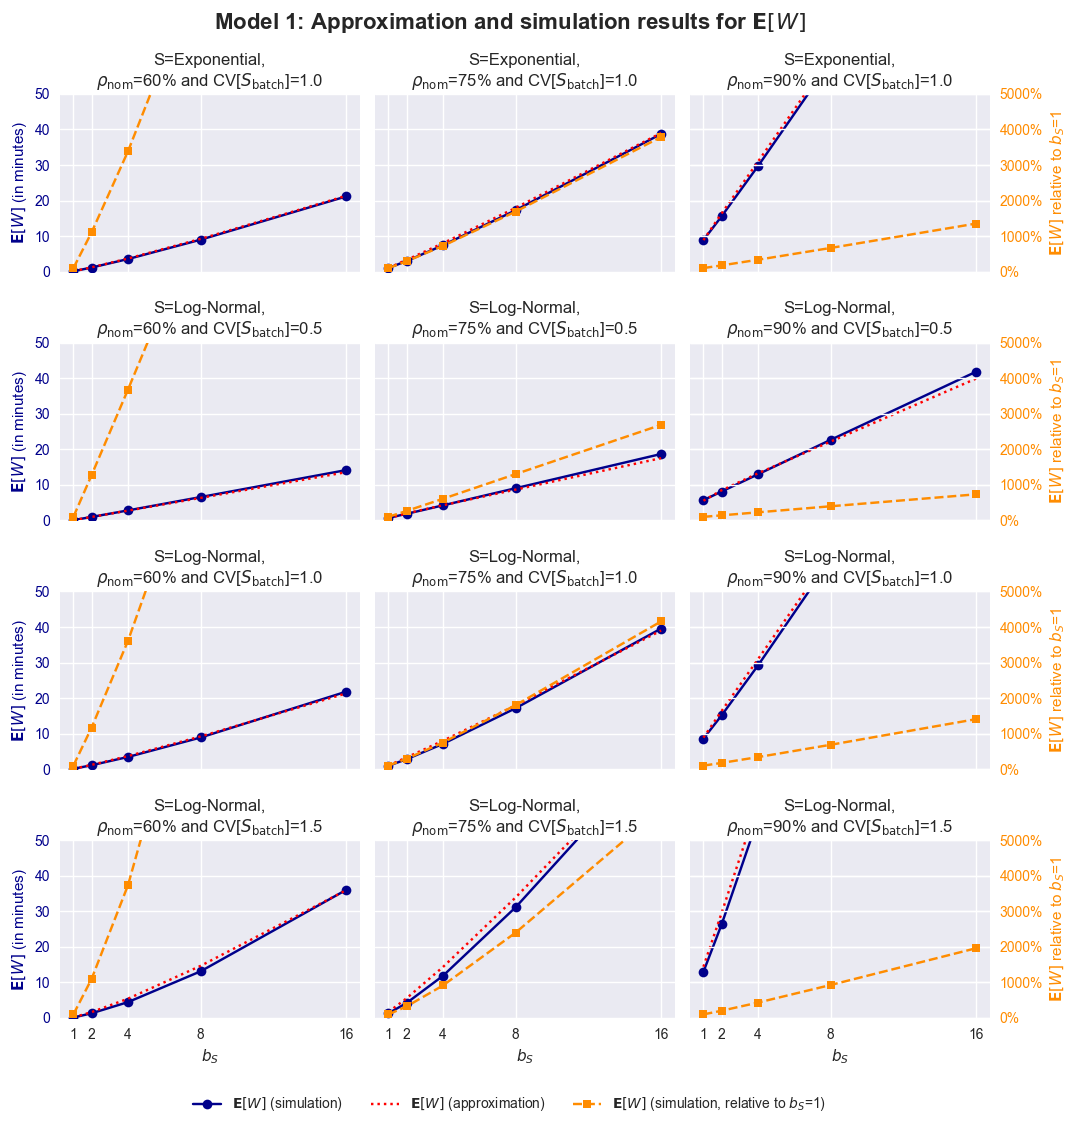

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1.0
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_abs_data = []
        plot_sim_rel_data = []
        plot_approx2_abs_data = []
        plot_approx2_rel_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_max"]
            name = rec["name_short"]
            approx = QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], rec["c"], 1, rec["b_max"], True)
            approx_base = QueueApprox.EW_approx(1 / 100, 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], c_needed, 1, 1, True)
            plot_sim_abs_data.append({"b": b, "name": name, "E[W]": rec["E[W]"]})
            plot_sim_rel_data.append({"b": b, "name": name, "E[W]": rec["E[W]rel"]})
            plot_approx2_abs_data.append({"b": b, "name": name, "E[W]": approx})
            plot_approx2_rel_data.append({"b": b, "name": name, "E[W]": approx / approx_base})

        plot_sim_abs_data = sorted(plot_sim_abs_data, key=lambda rec: rec["b"])
        plot_sim_rel_data = sorted(plot_sim_rel_data, key=lambda rec: rec["b"])
        plot_approx2_abs_data = sorted(plot_approx2_abs_data, key=lambda rec: rec["b"])
        plot_approx2_rel_data = sorted(plot_approx2_rel_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_rel_data]
        y_sim_abs = [rec["E[W]"] / 60 for rec in plot_sim_abs_data]
        y_sim_rel = [rec["E[W]"] for rec in plot_sim_rel_data]
        y_approx2_abs = [rec["E[W]"] / 60 for rec in plot_approx2_abs_data]
        y_approx2_rel = [rec["E[W]"] for rec in plot_approx2_rel_data]

        ax1 = ax[i][j]

        if i == 0 and j == 0:
            ax1.plot(x, y_sim_abs, marker='o', label="$\\mathbf{{E}}[W]$ (simulation)", color='darkblue')
            ax1.plot(x, y_approx2_abs, linestyle=':', color='red', label="$\\mathbf{{E}}[W]$ (approximation)")
        else:
            ax1.plot(x, y_sim_abs, marker='o', color='darkblue')
            ax1.plot(x, y_approx2_abs, linestyle=':', color='red')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("$\\mathbf{{E}}[W]$ (in minutes)", color='darkblue')
        ax1.tick_params(axis='y', colors='darkblue')
        ax1.set_ylim(0, 50)
        if i == 3:
            ax1.set_xlabel("$b_S$")

        ax2 = ax1.twinx()
        if i == 0 and j == 0:
            ax2.plot(x, y_sim_rel, marker='s', markersize=6, linestyle='--', color='darkorange', label='$\\mathbf{{E}}[W]$ (simulation, relative to $b_S$=1)')
        else:
            ax2.plot(x, y_sim_rel, marker='s', markersize=6, linestyle='--', color='darkorange')
        if j == 2:
            ax2.set_ylabel("$\\mathbf{{E}}[W]$ relative to $b_S$=1", color='darkorange')
        ax2.set_ylim(0, 50)
        if j != 2:
            ax2.set_yticks([])
        ax2.tick_params(axis='y', colors='darkorange')
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.suptitle("Model 1: Approximation and simulation results for $\\mathbf{E}[W]$", fontsize=16, fontweight="semibold", y=0.95)
fig.legend(loc='outside lower center', ncols=3, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model01-EW.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("images/BatchArithmeticAndMitigation-figure-results-Model01-EW.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

## Plotting ($b_I=1,\ldots,4$, $b_S=16$ (at $\rho\in\{60\%,75\%,90\%\}$ and $CV[S]\in\{0.5,1,1.5\}$))

### Plot E[W] (absolute)

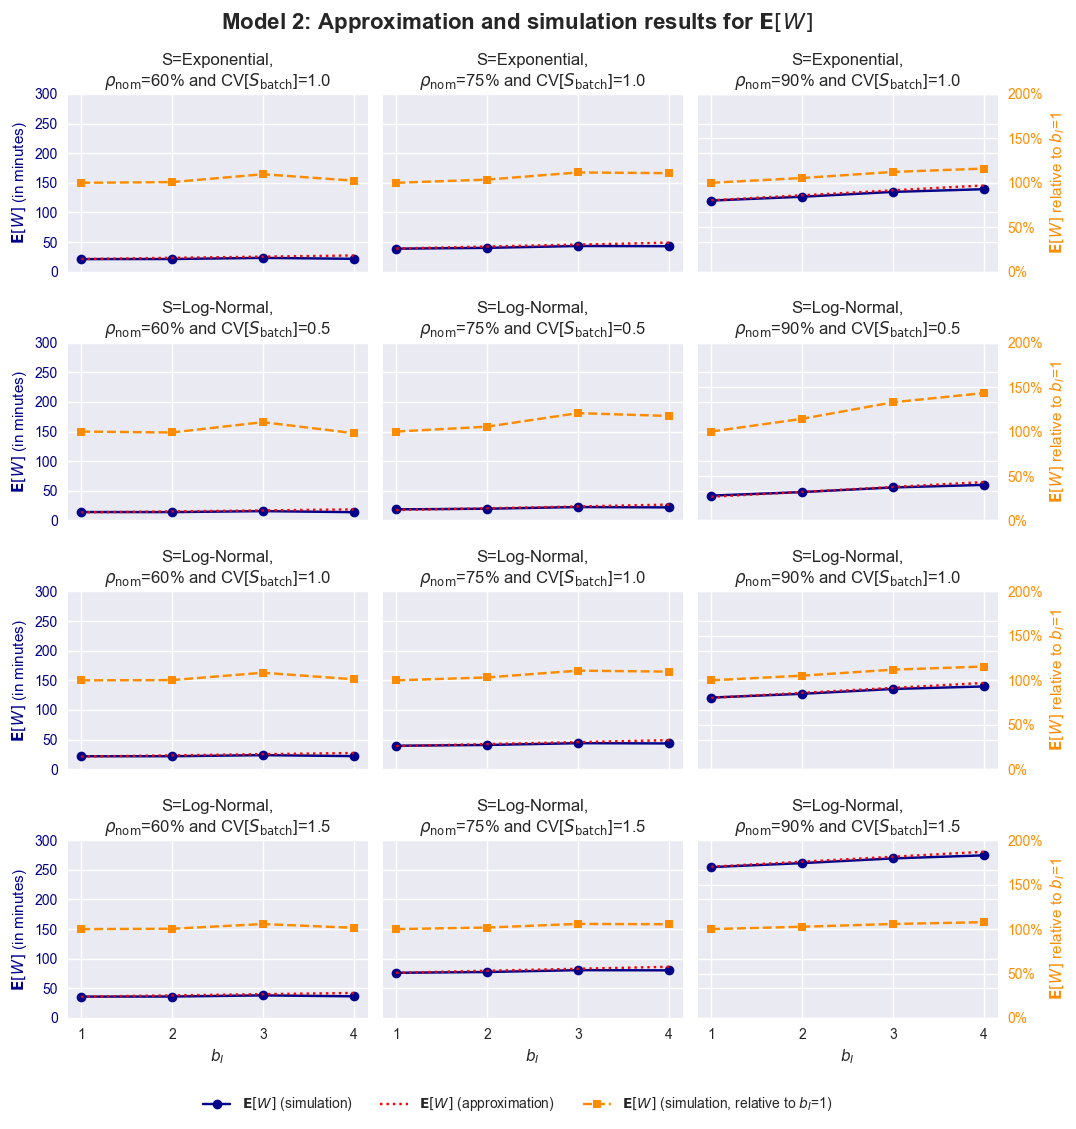

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1.0
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_abs_data = []
        plot_sim_rel_data = []
        plot_approx_data = []
        for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            bI = rec["bI"]
            name = rec["name_short"]
            plot_sim_abs_data.append({"bI": bI, "name": name, "E[W]": rec["E[W]"]/60})
            plot_sim_rel_data.append({"bI": bI, "name": name, "E[W]": rec["E[W]rel"]})
            plot_approx_data.append({"bI": bI, "name": name, "E[W]": QueueApprox.EW_approx(1 / 100 / rec["bI"], 1 / (100 * rho * c_needed), 1, rec["model_CV[S]"], 1, rec["bI"], c_needed, True)/60})

        plot_sim_abs_data = sorted(plot_sim_abs_data, key=lambda rec: rec["bI"])
        plot_sim_rel_data = sorted(plot_sim_rel_data, key=lambda rec: rec["bI"])
        plot_approx_data = sorted(plot_approx_data, key=lambda rec: rec["bI"])

        x = [rec["bI"] for rec in plot_sim_abs_data]
        y_sim_abs = [rec["E[W]"] for rec in plot_sim_abs_data]
        y_sim_rel = [rec["E[W]"] for rec in plot_sim_rel_data]
        y_approx_abs = [rec["E[W]"] for rec in plot_approx_data]

        ax1 = ax[i][j]

        if i==0 and j==0:
            ax1.plot(x, y_sim_abs, marker='o', label="$\\mathbf{{E}}[W]$ (simulation)", color='darkblue')
            ax1.plot(x, y_approx_abs, linestyle=':', color='red', label="$\\mathbf{{E}}[W]$ (approximation)")
        else:
            ax1.plot(x, y_sim_abs, marker='o', color='darkblue')
            ax1.plot(x, y_approx_abs, linestyle=':', color='red')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("$\\mathbf{{E}}[W]$ (in minutes)", color='darkblue')
        ax1.tick_params(axis='y', colors='darkblue')
        ax1.set_ylim(0, 300)
        if i == 3:
            ax1.set_xlabel("$b_I$")

        ax2 = ax1.twinx()
        if i==0 and j==0:
            ax2.plot(x, y_sim_rel, marker='s', markersize=6, linestyle='--', color='darkorange', label='$\\mathbf{{E}}[W]$ (simulation, relative to $b_I$=1)')
        else:
            ax2.plot(x, y_sim_rel, marker='s', markersize=6, linestyle='--', color='darkorange')
        if j == 2:
            ax2.set_ylabel("$\\mathbf{{E}}[W]$ relative to $b_I$=1", color='darkorange')
        ax2.set_ylim(0, 2)
        if j != 2:
            ax2.set_yticks([])
        ax2.tick_params(axis='y', colors='darkorange')
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.suptitle("Model 2: Approximation and simulation results for $\\mathbf{E}[W]$", fontsize=16, fontweight="semibold", y=0.95)
fig.legend(loc='outside lower center', ncols=3, bbox_to_anchor=(0.5, 0.02), fontsize=10)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model02-EW.png", format="png", bbox_inches='tight', pad_inches=0)

# fig.savefig("images/BatchArithmeticAndMitigation-figure-results-Model02-EW.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

### Plot CV[W]

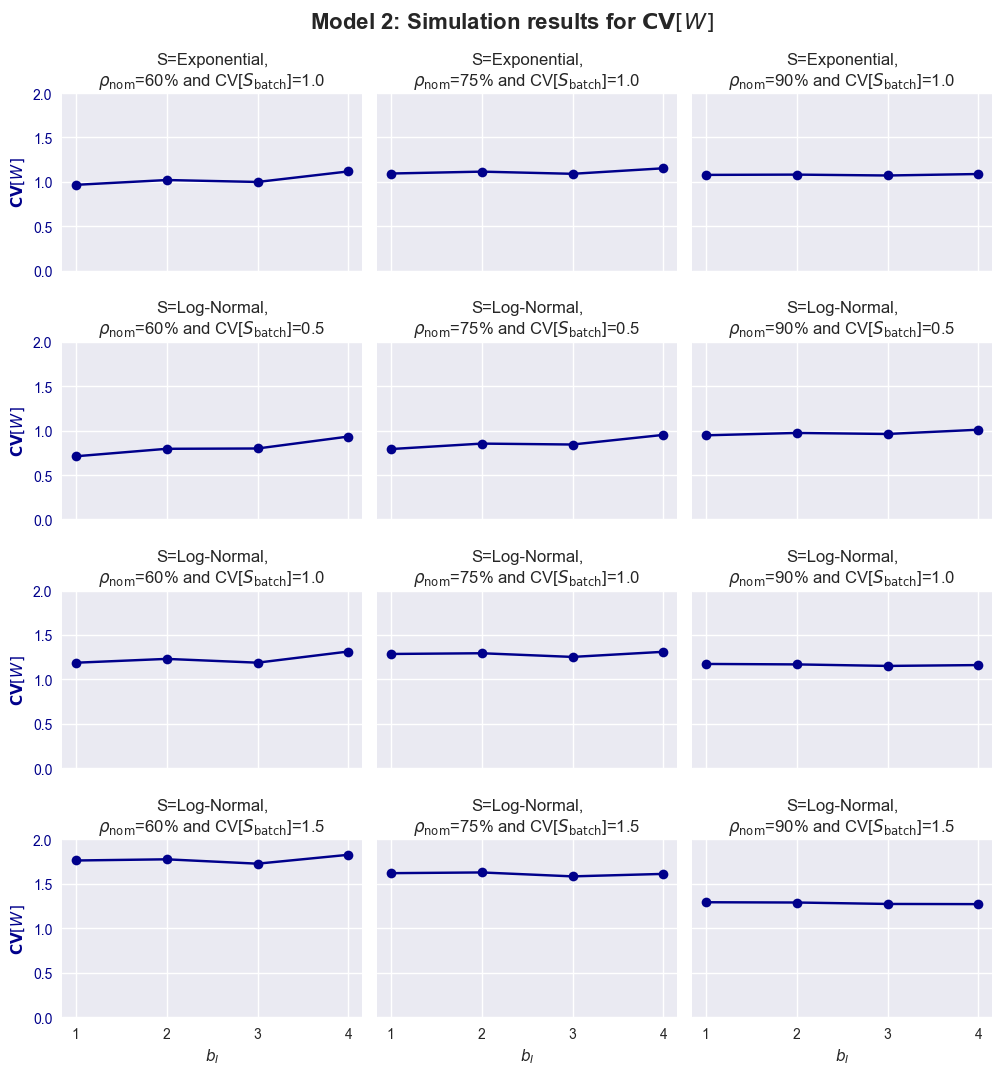

In [ ]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        S_name = "Exponential"
        CVS = 1.0
    else:
        S = "Log"
        S_name = "Log-Normal"
        CVS = 0.5 * i
    for j in range(3):
        rho = round(0.60 + j * 0.15, 2)
        plot_sim_data = []
        for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            bI = rec["bI"]
            name = rec["name_short"]
            plot_sim_data.append({"bI": bI, "name": name, "CV[W]": rec["CV[W]"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["bI"])

        x = [rec["bI"] for rec in plot_sim_data]
        y_sim = [rec["CV[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o', color='darkblue')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("$\\mathbf{{CV}}[W]$", color='darkblue')
        ax1.tick_params(axis='y', colors='darkblue')
        ax1.set_ylim(0, 2)
        if i == 3:
            ax1.set_xlabel("$b_I$")

        ax1.set_title(f"S={S_name},\n$\\rho_{{\\text{{nom}}}}$={rho * 100:0.0f}% and CV[$S_{{\\text{{batch}}}}$]={CVS}")

fig.suptitle("Model 2: Simulation results for $\\mathbf{CV}[W]$", fontsize=16, fontweight="semibold", y=0.95)
fig.subplots_adjust(wspace=0.05, hspace=0.4)

# fig.savefig("images/Model02-CVW.png", format="png", bbox_inches='tight', pad_inches=0)